In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

np.random.seed(42)

In [2]:
n = 2500

customer_ids = [f"CUST{10001+i}" for i in range(n)]

signup_dates = pd.date_range(
    start="2022-01-01",
    end="2025-06-30",
    freq="D"
)

plans = ["Basic", "Standard", "Premium"]
segments = ["Individual", "Small Business", "Enterprise"]
channels = ["Organic Search", "Social Media", "Referral", "Paid Ads", "Email"]
payment_methods = ["Credit Card", "Debit Card", "UPI", "PayPal"]

customers = pd.DataFrame({
    "Customer ID": customer_ids,
    "Signup Date": np.random.choice(signup_dates, n),
    "Plan": np.random.choice(
        plans,
        n,
        p=[0.40, 0.40, 0.20]
    ),
    "Customer Segment": np.random.choice(
        segments,
        n,
        p=[0.60, 0.28, 0.12]
    ),
    "Acquisition Channel": np.random.choice(
        channels,
        n,
        p=[0.25, 0.20, 0.20, 0.20, 0.15]
    ),
    "Payment Method": np.random.choice(
        payment_methods,
        n,
        p=[0.40, 0.25, 0.25, 0.10]
    )
})

customers.head()

,Customer ID,Signup Date,Plan,Customer Segment,Acquisition Channel,Payment Method
0,CUST10001,2025-01-31,Standard,Individual,Email,Debit Card
1,CUST10002,2024-05-10,Basic,Small Business,Organic Search,Credit Card
2,CUST10003,2025-02-04,Standard,Individual,Organic Search,Credit Card
3,CUST10004,2024-12-31,Basic,Small Business,Organic Search,Credit Card
4,CUST10005,2024-11-10,Standard,Small Business,Email,Debit Card


In [3]:
analysis_end = pd.Timestamp("2025-12-31")

plan_fee = {
    "Basic": 19,
    "Standard": 39,
    "Premium": 69
}

customers["Monthly Fee"] = customers["Plan"].map(plan_fee)

customers["Maximum Tenure Days"] = (
    analysis_end - customers["Signup Date"]
).dt.days

base_churn = customers["Plan"].map({
    "Basic": 0.34,
    "Standard": 0.25,
    "Premium": 0.16
})

segment_effect = customers["Customer Segment"].map({
    "Individual": 0.06,
    "Small Business": 0.02,
    "Enterprise": -0.04
})

channel_effect = customers["Acquisition Channel"].map({
    "Organic Search": -0.02,
    "Social Media": 0.04,
    "Referral": -0.05,
    "Paid Ads": 0.08,
    "Email": 0.00
})

payment_effect = customers["Payment Method"].map({
    "Credit Card": 0.00,
    "Debit Card": 0.04,
    "UPI": -0.02,
    "PayPal": 0.06
})

tenure_effect = np.where(
    customers["Maximum Tenure Days"] < 180, 0.12,
    np.where(customers["Maximum Tenure Days"] < 365, 0.05, -0.02)
)

churn_probability = (
    base_churn
    + segment_effect
    + channel_effect
    + payment_effect
    + tenure_effect
)

churn_probability = np.clip(churn_probability, 0.05, 0.70)

customers["Churn Flag"] = (
    np.random.random(n) < churn_probability
).astype(int)

customers["Churn Status"] = np.where(
    customers["Churn Flag"] == 1,
    "Churned",
    "Active"
)

churn_dates = []

for i, row in customers.iterrows():
    if row["Churn Flag"] == 1:
        min_days = min(30, max(1, row["Maximum Tenure Days"]))
        max_days = max(min_days, row["Maximum Tenure Days"])

        churn_day = np.random.randint(
            min_days,
            max_days + 1
        )

        churn_dates.append(
            row["Signup Date"] + pd.Timedelta(days=int(churn_day))
        )
    else:
        churn_dates.append(pd.NaT)

customers["Churn Date"] = pd.to_datetime(churn_dates)

customers["End Date"] = customers["Churn Date"].fillna(analysis_end)

customers["Tenure Days"] = (
    customers["End Date"] - customers["Signup Date"]
).dt.days

customers["Tenure Months"] = (
    customers["Tenure Days"] / 30.44
).round(1)

customers["Estimated Lifetime Value"] = (
    customers["Monthly Fee"] * customers["Tenure Months"]
).round(2)

customers.head()

,Customer ID,Signup Date,Plan,Customer Segment,Acquisition Channel,Payment Method,Monthly Fee,Maximum Tenure Days,Churn Flag,Churn Status,Churn Date,End Date,Tenure Days,Tenure Months,Estimated Lifetime Value
0,CUST10001,2025-01-31,Standard,Individual,Email,Debit Card,39,334,1,Churned,2025-12-28,2025-12-28,331,10.9,425.1
1,CUST10002,2024-05-10,Basic,Small Business,Organic Search,Credit Card,19,600,1,Churned,2024-12-13,2024-12-13,217,7.1,134.9
2,CUST10003,2025-02-04,Standard,Individual,Organic Search,Credit Card,39,330,0,Active,NaT,2025-12-31,330,10.8,421.2
3,CUST10004,2024-12-31,Basic,Small Business,Organic Search,Credit Card,19,365,1,Churned,2025-09-26,2025-09-26,269,8.8,167.2
4,CUST10005,2024-11-10,Standard,Small Business,Email,Debit Card,39,416,0,Active,NaT,2025-12-31,416,13.7,534.3


In [4]:
usage_base = customers["Plan"].map({
    "Basic": 18,
    "Standard": 28,
    "Premium": 38
})

customers["Monthly Usage Hours"] = np.maximum(
    2,
    np.random.normal(usage_base, 8)
).round(1)

customers["Support Tickets"] = np.random.poisson(
    2.5, n
)

satisfaction = (
    4.1
    - customers["Support Tickets"] * 0.12
    + customers["Monthly Usage Hours"] * 0.01
    + np.random.normal(0, 0.35, n)
)

customers["Satisfaction Score"] = np.clip(
    satisfaction, 1, 5
).round(1)

churn_reasons = [
    "Price Too High",
    "Poor Service Experience",
    "Missing Features",
    "Payment Issues",
    "Switched to Competitor",
    "Low Usage"
]

reason_prob = [
    0.22, 0.18, 0.17, 0.12, 0.18, 0.13
]

customers["Churn Reason"] = np.where(
    customers["Churn Flag"] == 1,
    np.random.choice(
        churn_reasons,
        n,
        p=reason_prob
    ),
    "Not Applicable"
)

customers.head()

,Customer ID,Signup Date,Plan,Customer Segment,Acquisition Channel,Payment Method,Monthly Fee,Maximum Tenure Days,Churn Flag,Churn Status,Churn Date,End Date,Tenure Days,Tenure Months,Estimated Lifetime Value,Monthly Usage Hours,Support Tickets,Satisfaction Score,Churn Reason
0,CUST10001,2025-01-31,Standard,Individual,Email,Debit Card,39,334,1,Churned,2025-12-28,2025-12-28,331,10.9,425.1,40.4,2,4.5,Low Usage
1,CUST10002,2024-05-10,Basic,Small Business,Organic Search,Credit Card,19,600,1,Churned,2024-12-13,2024-12-13,217,7.1,134.9,4.6,1,3.8,Price Too High
2,CUST10003,2025-02-04,Standard,Individual,Organic Search,Credit Card,39,330,0,Active,NaT,2025-12-31,330,10.8,421.2,12.6,3,2.9,Not Applicable
3,CUST10004,2024-12-31,Basic,Small Business,Organic Search,Credit Card,19,365,1,Churned,2025-09-26,2025-09-26,269,8.8,167.2,17.3,0,4.7,Payment Issues
4,CUST10005,2024-11-10,Standard,Small Business,Email,Debit Card,39,416,0,Active,NaT,2025-12-31,416,13.7,534.3,43.3,5,3.2,Not Applicable


In [5]:
customers["Signup Date"] = pd.to_datetime(
    customers["Signup Date"]
)

customers["Churn Date"] = pd.to_datetime(
    customers["Churn Date"]
)

customers["Signup Month"] = (
    customers["Signup Date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

customers["Churn Month"] = (
    customers["Churn Date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

customers["Cohort"] = (
    customers["Signup Date"]
    .dt.to_period("M")
    .astype(str)
)

customers["Signup Year"] = (
    customers["Signup Date"].dt.year
)

customers["Tenure Group"] = pd.cut(
    customers["Tenure Months"],
    bins=[0, 3, 6, 12, 24, 100],
    labels=[
        "0–3 Months",
        "3–6 Months",
        "6–12 Months",
        "1–2 Years",
        "2+ Years"
    ],
    include_lowest=True
)

customers.head()

,Customer ID,Signup Date,Plan,Customer Segment,Acquisition Channel,Payment Method,Monthly Fee,Maximum Tenure Days,Churn Flag,Churn Status,Churn Date,End Date,Tenure Days,Tenure Months,Estimated Lifetime Value,Monthly Usage Hours,Support Tickets,Satisfaction Score,Churn Reason,Signup Month,Churn Month,Cohort,Signup Year,Tenure Group
0,CUST10001,2025-01-31,Standard,Individual,Email,Debit Card,39,334,1,Churned,2025-12-28,2025-12-28,331,10.9,425.1,40.4,2,4.5,Low Usage,2025-01-01,2025-12-01,2025-01,2025,6–12 Months
1,CUST10002,2024-05-10,Basic,Small Business,Organic Search,Credit Card,19,600,1,Churned,2024-12-13,2024-12-13,217,7.1,134.9,4.6,1,3.8,Price Too High,2024-05-01,2024-12-01,2024-05,2024,6–12 Months
2,CUST10003,2025-02-04,Standard,Individual,Organic Search,Credit Card,39,330,0,Active,NaT,2025-12-31,330,10.8,421.2,12.6,3,2.9,Not Applicable,2025-02-01,NaT,2025-02,2025,6–12 Months
3,CUST10004,2024-12-31,Basic,Small Business,Organic Search,Credit Card,19,365,1,Churned,2025-09-26,2025-09-26,269,8.8,167.2,17.3,0,4.7,Payment Issues,2024-12-01,2025-09-01,2024-12,2024,6–12 Months
4,CUST10005,2024-11-10,Standard,Small Business,Email,Debit Card,39,416,0,Active,NaT,2025-12-31,416,13.7,534.3,43.3,5,3.2,Not Applicable,2024-11-01,NaT,2024-11,2024,1–2 Years


In [6]:
total_customers = len(customers)
churned_customers = customers["Churn Flag"].sum()
active_customers = total_customers - churned_customers

churn_rate = churned_customers / total_customers * 100
retention_rate = active_customers / total_customers * 100

avg_tenure = customers["Tenure Months"].mean()
avg_lifetime_value = customers["Estimated Lifetime Value"].mean()

total_revenue_at_risk = (
    customers.loc[
        customers["Churn Flag"] == 1,
        "Monthly Fee"
    ].sum()
)

kpis = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Active Customers",
        "Churned Customers",
        "Churn Rate (%)",
        "Retention Rate (%)",
        "Average Tenure (Months)",
        "Average Lifetime Value",
        "Monthly Revenue at Risk"
    ],
    "Value": [
        total_customers,
        active_customers,
        churned_customers,
        round(churn_rate, 2),
        round(retention_rate, 2),
        round(avg_tenure, 2),
        round(avg_lifetime_value, 2),
        round(total_revenue_at_risk, 2)
    ]
})

display(kpis)

,Metric,Value
0,Total Customers,2500.00
1,Active Customers,1681.00
2,Churned Customers,819.00
3,Churn Rate (%),32.76
4,Retention Rate (%),67.24
5,Average Tenure (Months),22.59
6,Average Lifetime Value,842.90
7,Monthly Revenue at Risk,27451.00


In [7]:
plan_churn = (
    customers.groupby("Plan")
    .agg(
        Customers=("Customer ID", "count"),
        Churned=("Churn Flag", "sum"),
        Avg_Tenure=("Tenure Months", "mean"),
        Avg_LTV=("Estimated Lifetime Value", "mean")
    )
)

plan_churn["Churn Rate (%)"] = (
    plan_churn["Churned"]
    / plan_churn["Customers"] * 100
)

segment_churn = (
    customers.groupby("Customer Segment")
    .agg(
        Customers=("Customer ID", "count"),
        Churned=("Churn Flag", "sum")
    )
)

segment_churn["Churn Rate (%)"] = (
    segment_churn["Churned"]
    / segment_churn["Customers"] * 100
)

channel_churn = (
    customers.groupby("Acquisition Channel")
    .agg(
        Customers=("Customer ID", "count"),
        Churned=("Churn Flag", "sum")
    )
)

channel_churn["Churn Rate (%)"] = (
    channel_churn["Churned"]
    / channel_churn["Customers"] * 100
)

print("Churn by Plan")
display(plan_churn.round(2))

print("Churn by Customer Segment")
display(segment_churn.round(2))

print("Churn by Acquisition Channel")
display(channel_churn.round(2))

Churn by Plan


,Customers,Churned,Avg_Tenure,Avg_LTV,Churn Rate (%)
Plan,,,,,
Basic,1018,382,21.80,414.22,37.52
Premium,489,105,23.75,1638.73,21.47
Standard,993,332,22.83,890.45,33.43


Churn by Customer Segment


,Customers,Churned,Churn Rate (%)
Customer Segment,,,
Enterprise,305,70,22.95
Individual,1531,538,35.14
Small Business,664,211,31.78


Churn by Acquisition Channel


,Customers,Churned,Churn Rate (%)
Acquisition Channel,,,
Email,351,112,31.91
Organic Search,624,181,29.01
Paid Ads,470,190,40.43
Referral,523,131,25.05
Social Media,532,205,38.53


Churn by Tenure Group


,Customers,Churned,Churn Rate (%)
Tenure Group,,,
0–3 Months,80,80,100.00
3–6 Months,150,146,97.33
6–12 Months,440,220,50.00
1–2 Years,753,231,30.68
2+ Years,1077,142,13.18


Churn by Payment Method


,Customers,Churned,Churn Rate (%)
Payment Method,,,
Credit Card,997,314,31.49
Debit Card,620,223,35.97
PayPal,253,97,38.34
UPI,630,185,29.37


Churn Reasons


,Churn Reason,Customers,Percentage (%)
4,Price Too High,190,23.20
5,Switched to Competitor,163,19.90
3,Poor Service Experience,148,18.07
1,Missing Features,127,15.51
0,Low Usage,110,13.43
2,Payment Issues,81,9.89


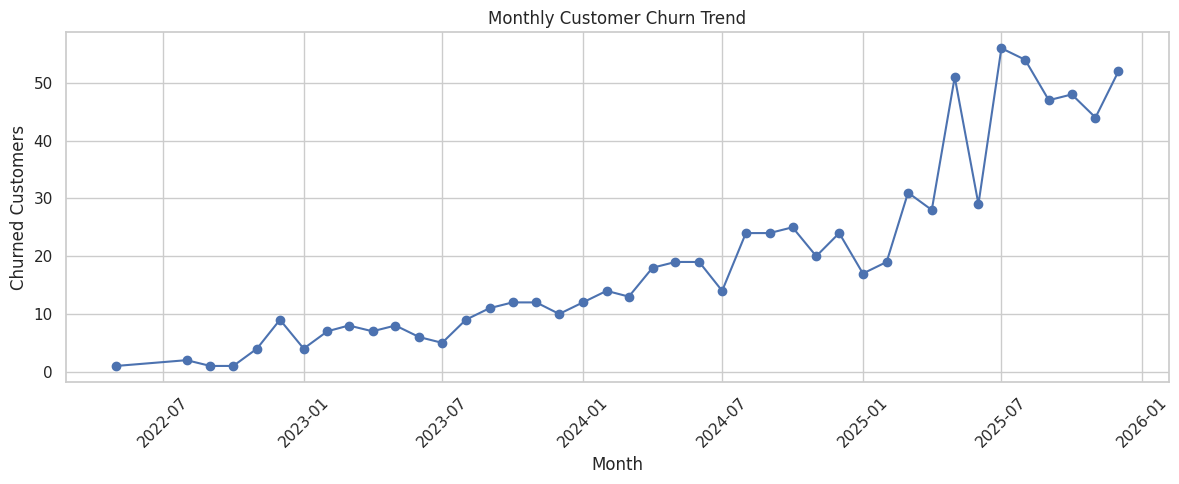

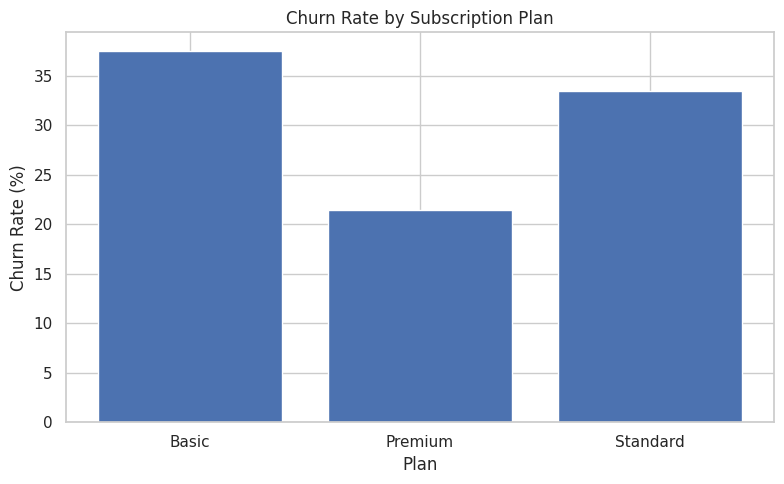

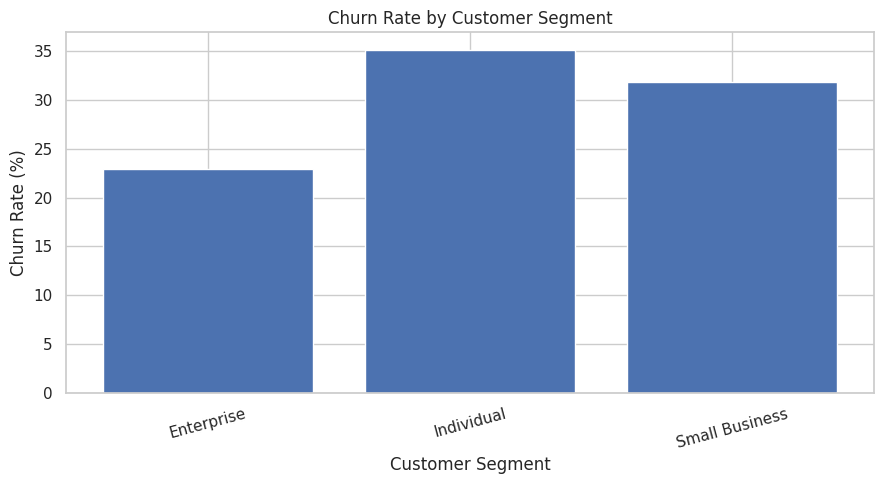

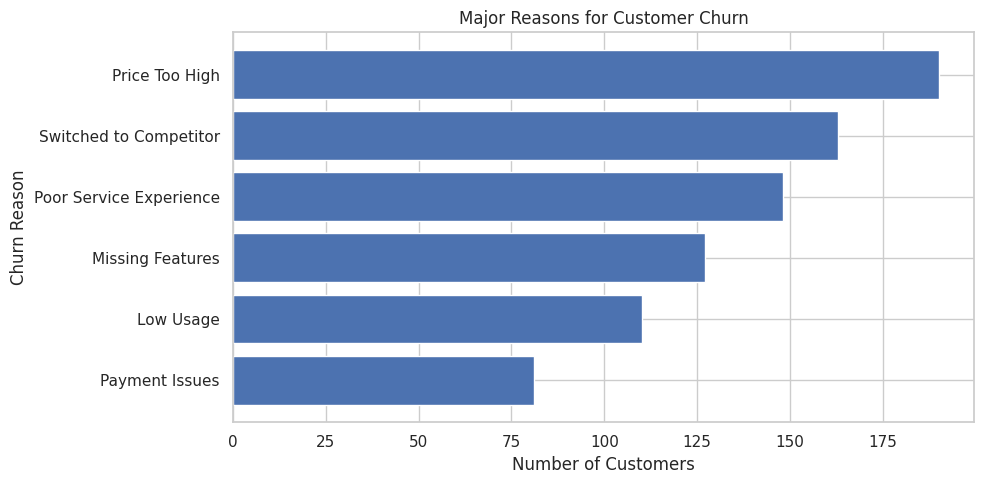

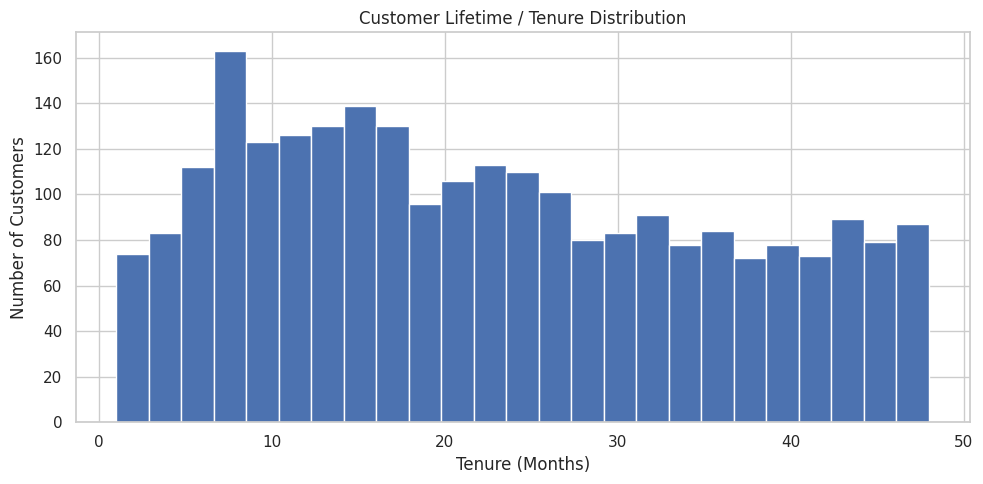

Cohort Retention Analysis


,Cohort,Total_Customers,Active_Customers,Retention Rate (%)
0,2022-01,73,50,68.49
1,2022-02,56,39,69.64
2,2022-03,53,38,71.70
3,2022-04,63,47,74.60
4,2022-05,71,47,66.20
5,2022-06,48,38,79.17
6,2022-07,52,36,69.23
7,2022-08,57,42,73.68
8,2022-09,46,33,71.74
9,2022-10,49,33,67.35


Customer Lifetime Analysis


,Average_Tenure_Months,Average_LTV,Total_Customers
Plan,,,
Basic,21.80,414.22,1018
Premium,23.75,1638.73,489
Standard,22.83,890.45,993


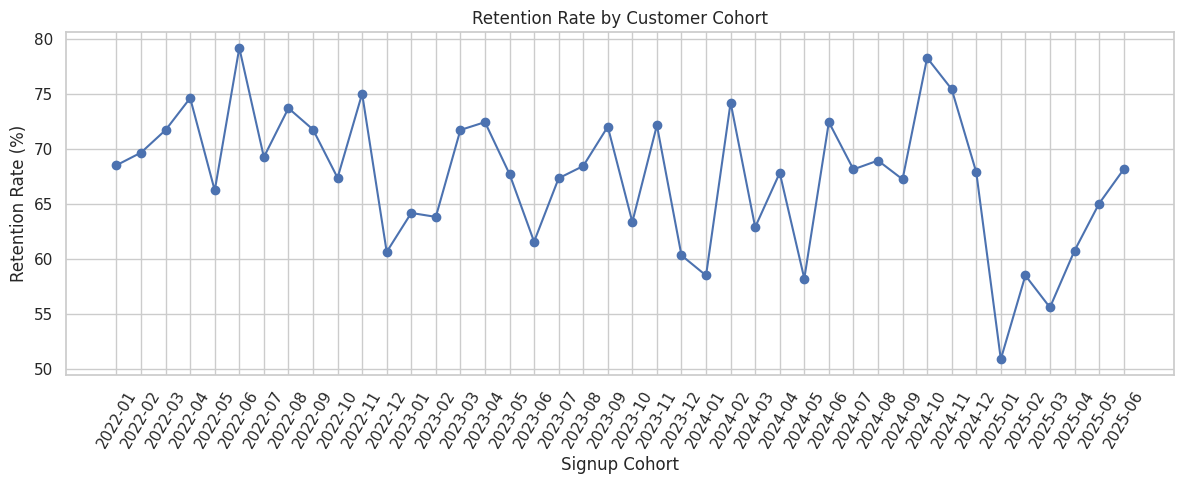

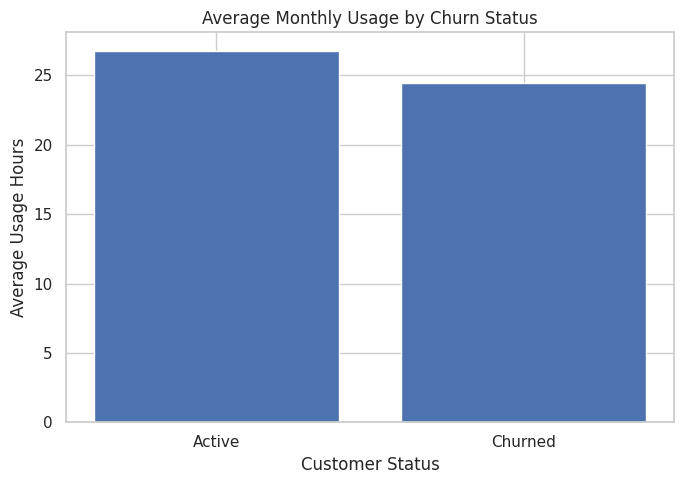

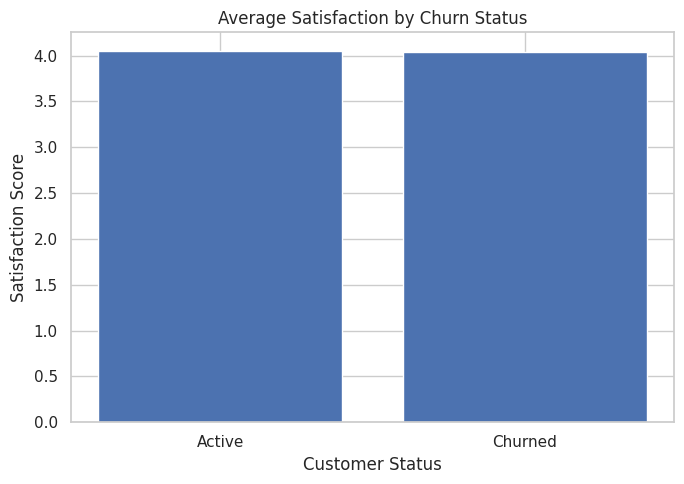


KEY BUSINESS INSIGHTS
--------------------------------------------------
Overall churn rate: 32.76%
Overall retention rate: 67.24%
Highest churn plan: Basic
Highest churn customer segment: Individual
Highest churn acquisition channel: Paid Ads
Highest churn payment method: PayPal
Most common churn reason: Price Too High
Average customer tenure: 22.59 months
Average customer lifetime value: 842.90
Monthly revenue at risk: 27451.00
Average usage of active customers: 26.77 hours
Average usage of churned customers: 24.47 hours
Average satisfaction of active customers: 4.05
Average satisfaction of churned customers: 4.04


In [8]:
# Cell 8 — Retention, Churn, Cohort & Lifetime Analysis

# 1. Churn by Tenure Group
tenure_churn = (
    customers.groupby("Tenure Group", observed=True)
    .agg(
        Customers=("Customer ID", "count"),
        Churned=("Churn Flag", "sum")
    )
)

tenure_churn["Churn Rate (%)"] = (
    tenure_churn["Churned"]
    / tenure_churn["Customers"] * 100
)

print("Churn by Tenure Group")
display(tenure_churn.round(2))


# 2. Churn by Payment Method
payment_churn = (
    customers.groupby("Payment Method")
    .agg(
        Customers=("Customer ID", "count"),
        Churned=("Churn Flag", "sum")
    )
)

payment_churn["Churn Rate (%)"] = (
    payment_churn["Churned"]
    / payment_churn["Customers"] * 100
)

print("Churn by Payment Method")
display(payment_churn.round(2))


# 3. Churn Reasons
churn_reasons_analysis = (
    customers[customers["Churn Flag"] == 1]
    .groupby("Churn Reason")
    .size()
    .reset_index(name="Customers")
    .sort_values("Customers", ascending=False)
)

churn_reasons_analysis["Percentage (%)"] = (
    churn_reasons_analysis["Customers"]
    / churn_reasons_analysis["Customers"].sum() * 100
)

print("Churn Reasons")
display(churn_reasons_analysis.round(2))


# 4. Monthly Churn Trend
monthly_churn = (
    customers[customers["Churn Flag"] == 1]
    .groupby("Churn Month")
    .size()
    .reset_index(name="Churned Customers")
)

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_churn["Churn Month"],
    monthly_churn["Churned Customers"],
    marker="o"
)
plt.title("Monthly Customer Churn Trend")
plt.xlabel("Month")
plt.ylabel("Churned Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 5. Churn Rate by Plan
plt.figure(figsize=(8, 5))
plt.bar(
    plan_churn.index,
    plan_churn["Churn Rate (%)"]
)
plt.title("Churn Rate by Subscription Plan")
plt.xlabel("Plan")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()


# 6. Churn Rate by Customer Segment
plt.figure(figsize=(9, 5))
plt.bar(
    segment_churn.index,
    segment_churn["Churn Rate (%)"]
)
plt.title("Churn Rate by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


# 7. Churn Reasons Chart
plt.figure(figsize=(10, 5))
plt.barh(
    churn_reasons_analysis["Churn Reason"],
    churn_reasons_analysis["Customers"]
)
plt.title("Major Reasons for Customer Churn")
plt.xlabel("Number of Customers")
plt.ylabel("Churn Reason")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# 8. Tenure Distribution
plt.figure(figsize=(10, 5))
plt.hist(
    customers["Tenure Months"],
    bins=25
)
plt.title("Customer Lifetime / Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


# 9. Cohort Retention Analysis
cohort_data = (
    customers.groupby("Cohort")
    .agg(
        Total_Customers=("Customer ID", "count"),
        Active_Customers=("Churn Flag", lambda x: (x == 0).sum())
    )
)

cohort_data["Retention Rate (%)"] = (
    cohort_data["Active_Customers"]
    / cohort_data["Total_Customers"] * 100
)

cohort_data = cohort_data.reset_index()

print("Cohort Retention Analysis")
display(cohort_data.round(2))


# 10. Customer Lifetime Summary
lifetime_summary = customers.groupby("Plan").agg(
    Average_Tenure_Months=("Tenure Months", "mean"),
    Average_LTV=("Estimated Lifetime Value", "mean"),
    Total_Customers=("Customer ID", "count")
)

print("Customer Lifetime Analysis")
display(lifetime_summary.round(2))


# 11. Retention Trend by Cohort
plt.figure(figsize=(12, 5))
plt.plot(
    cohort_data["Cohort"],
    cohort_data["Retention Rate (%)"],
    marker="o"
)
plt.title("Retention Rate by Customer Cohort")
plt.xlabel("Signup Cohort")
plt.ylabel("Retention Rate (%)")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()


# 12. Usage vs Churn
usage_summary = customers.groupby("Churn Status")[
    "Monthly Usage Hours"
].mean()

plt.figure(figsize=(7, 5))
plt.bar(
    usage_summary.index,
    usage_summary.values
)
plt.title("Average Monthly Usage by Churn Status")
plt.xlabel("Customer Status")
plt.ylabel("Average Usage Hours")
plt.tight_layout()
plt.show()


# 13. Satisfaction vs Churn
satisfaction_summary = customers.groupby("Churn Status")[
    "Satisfaction Score"
].mean()

plt.figure(figsize=(7, 5))
plt.bar(
    satisfaction_summary.index,
    satisfaction_summary.values
)
plt.title("Average Satisfaction by Churn Status")
plt.xlabel("Customer Status")
plt.ylabel("Satisfaction Score")
plt.tight_layout()
plt.show()


# 14. Key Insights
highest_plan_churn = plan_churn["Churn Rate (%)"].idxmax()
highest_segment_churn = segment_churn["Churn Rate (%)"].idxmax()
highest_channel_churn = channel_churn["Churn Rate (%)"].idxmax()
highest_payment_churn = payment_churn["Churn Rate (%)"].idxmax()
top_churn_reason = churn_reasons_analysis.iloc[0]["Churn Reason"]

active_usage = customers.loc[
    customers["Churn Status"] == "Active",
    "Monthly Usage Hours"
].mean()

churned_usage = customers.loc[
    customers["Churn Status"] == "Churned",
    "Monthly Usage Hours"
].mean()

active_satisfaction = customers.loc[
    customers["Churn Status"] == "Active",
    "Satisfaction Score"
].mean()

churned_satisfaction = customers.loc[
    customers["Churn Status"] == "Churned",
    "Satisfaction Score"
].mean()

print("\nKEY BUSINESS INSIGHTS")
print("-" * 50)
print(f"Overall churn rate: {churn_rate:.2f}%")
print(f"Overall retention rate: {retention_rate:.2f}%")
print(f"Highest churn plan: {highest_plan_churn}")
print(f"Highest churn customer segment: {highest_segment_churn}")
print(f"Highest churn acquisition channel: {highest_channel_churn}")
print(f"Highest churn payment method: {highest_payment_churn}")
print(f"Most common churn reason: {top_churn_reason}")
print(f"Average customer tenure: {avg_tenure:.2f} months")
print(f"Average customer lifetime value: {avg_lifetime_value:.2f}")
print(f"Monthly revenue at risk: {total_revenue_at_risk:.2f}")
print(f"Average usage of active customers: {active_usage:.2f} hours")
print(f"Average usage of churned customers: {churned_usage:.2f} hours")
print(f"Average satisfaction of active customers: {active_satisfaction:.2f}")
print(f"Average satisfaction of churned customers: {churned_satisfaction:.2f}")

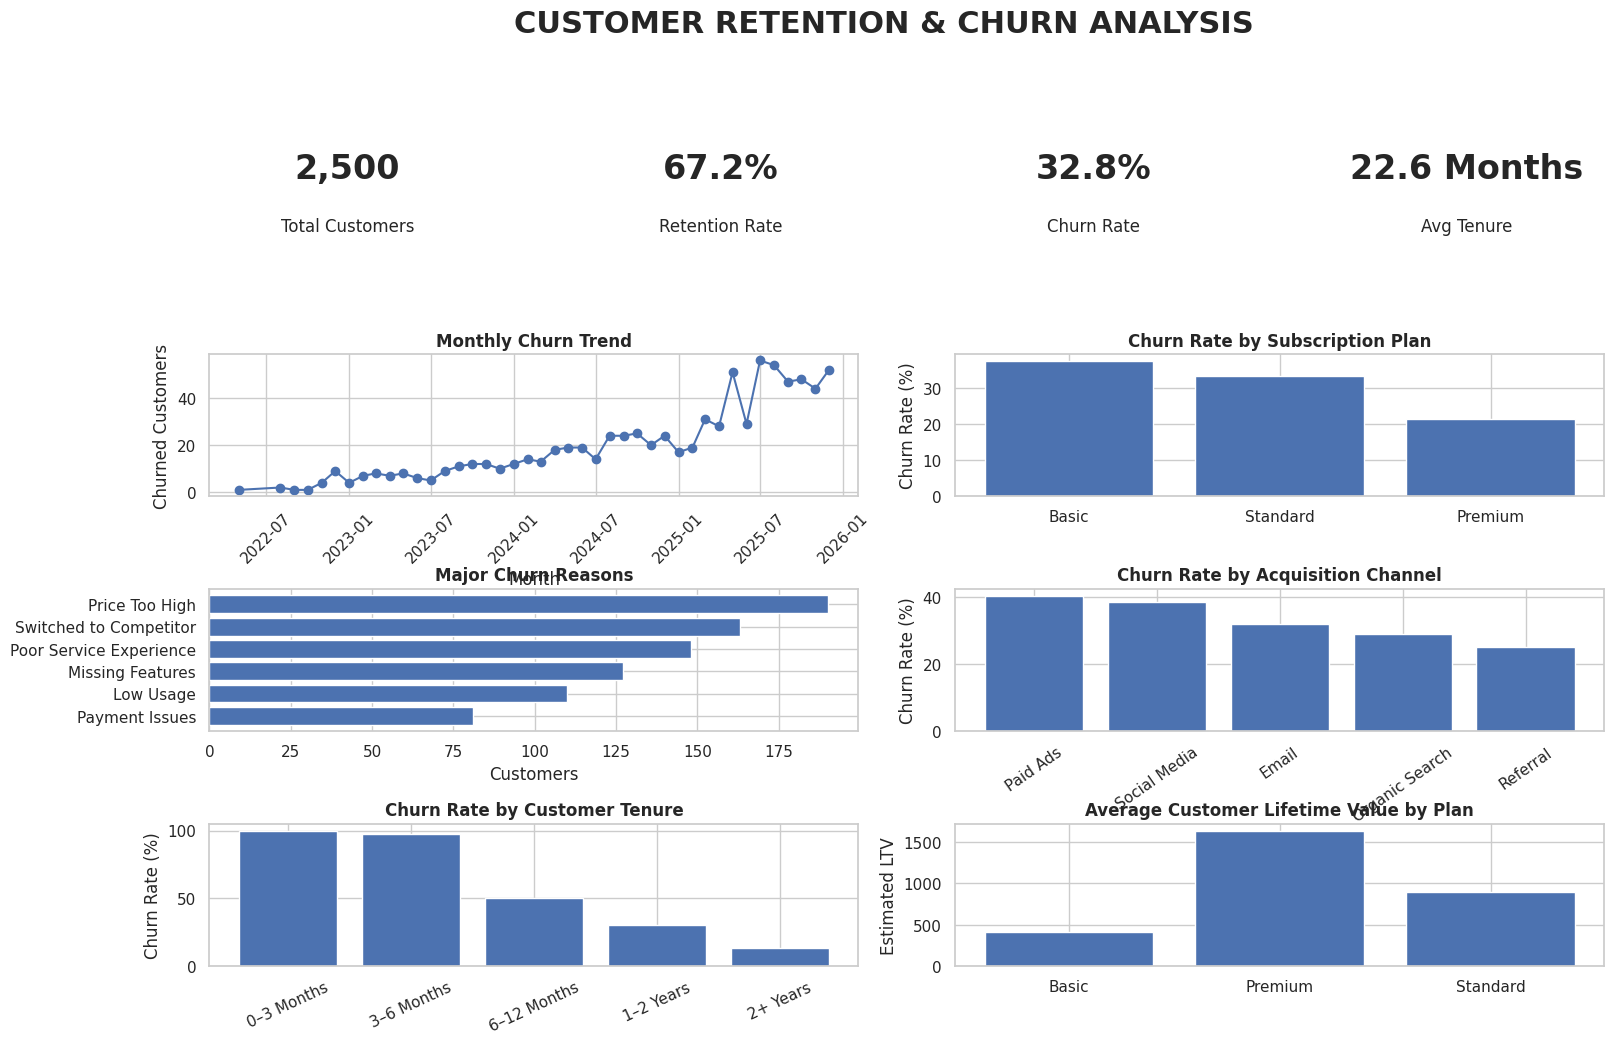

Project files created successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
# Final Dashboard and Project Export

from matplotlib.gridspec import GridSpec

# -----------------------------
# Dashboard calculations
# -----------------------------

total_customers = len(customers)
active_customers = (customers["Churn Status"] == "Active").sum()
churned_customers = (customers["Churn Status"] == "Churned").sum()

churn_rate = churned_customers / total_customers * 100
retention_rate = active_customers / total_customers * 100
avg_tenure = customers["Tenure Months"].mean()
avg_ltv = customers["Estimated Lifetime Value"].mean()

# Monthly churn trend
monthly_churn = (
    customers[customers["Churn Flag"] == 1]
    .groupby("Churn Month")
    .size()
)

# Top churn reasons
reason_data = (
    customers[customers["Churn Flag"] == 1]
    .groupby("Churn Reason")
    .size()
    .sort_values(ascending=False)
)

# Plan churn
plan_data = (
    customers.groupby("Plan")["Churn Flag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

# Region-style equivalent: acquisition channel
channel_data = (
    customers.groupby("Acquisition Channel")["Churn Flag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

# Tenure churn
tenure_data = (
    customers.groupby("Tenure Group", observed=True)["Churn Flag"]
    .mean()
    .mul(100)
)

# -----------------------------
# Create dashboard
# -----------------------------

fig = plt.figure(figsize=(18, 11))
gs = GridSpec(4, 4, figure=fig, hspace=0.65, wspace=0.35)

fig.suptitle(
    "CUSTOMER RETENTION & CHURN ANALYSIS",
    fontsize=22,
    fontweight="bold",
    y=0.98
)

# KPI cards
kpis_dashboard = [
    ("Total Customers", f"{total_customers:,}"),
    ("Retention Rate", f"{retention_rate:.1f}%"),
    ("Churn Rate", f"{churn_rate:.1f}%"),
    ("Avg Tenure", f"{avg_tenure:.1f} Months")
]

for i, (title, value) in enumerate(kpis_dashboard):
    ax = fig.add_subplot(gs[0, i])
    ax.axis("off")
    ax.text(
        0.5, 0.65, value,
        ha="center",
        va="center",
        fontsize=24,
        fontweight="bold"
    )
    ax.text(
        0.5, 0.25, title,
        ha="center",
        va="center",
        fontsize=12
    )

# Monthly churn trend
ax1 = fig.add_subplot(gs[1, :2])
ax1.plot(
    monthly_churn.index,
    monthly_churn.values,
    marker="o"
)
ax1.set_title("Monthly Churn Trend", fontweight="bold")
ax1.set_xlabel("Month")
ax1.set_ylabel("Churned Customers")
ax1.tick_params(axis="x", rotation=45)

# Churn by plan
ax2 = fig.add_subplot(gs[1, 2:])
ax2.bar(
    plan_data.index,
    plan_data.values
)
ax2.set_title("Churn Rate by Subscription Plan", fontweight="bold")
ax2.set_ylabel("Churn Rate (%)")

# Churn reasons
ax3 = fig.add_subplot(gs[2, :2])
ax3.barh(
    reason_data.index,
    reason_data.values
)
ax3.set_title("Major Churn Reasons", fontweight="bold")
ax3.set_xlabel("Customers")
ax3.invert_yaxis()

# Acquisition channel
ax4 = fig.add_subplot(gs[2, 2:])
ax4.bar(
    channel_data.index,
    channel_data.values
)
ax4.set_title("Churn Rate by Acquisition Channel", fontweight="bold")
ax4.set_ylabel("Churn Rate (%)")
ax4.tick_params(axis="x", rotation=35)

# Tenure analysis
ax5 = fig.add_subplot(gs[3, :2])
ax5.bar(
    tenure_data.index.astype(str),
    tenure_data.values
)
ax5.set_title("Churn Rate by Customer Tenure", fontweight="bold")
ax5.set_ylabel("Churn Rate (%)")
ax5.tick_params(axis="x", rotation=25)

# Customer lifetime
plan_ltv = customers.groupby("Plan")["Estimated Lifetime Value"].mean()

ax6 = fig.add_subplot(gs[3, 2:])
ax6.bar(
    plan_ltv.index,
    plan_ltv.values
)
ax6.set_title("Average Customer Lifetime Value by Plan", fontweight="bold")
ax6.set_ylabel("Estimated LTV")

plt.savefig(
    "Retention_Dashboard.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# -----------------------------
# Excel workbook
# -----------------------------

with pd.ExcelWriter(
    "Customer_Retention_Analysis.xlsx",
    engine="openpyxl"
) as writer:

    customers.to_excel(
        writer,
        sheet_name="Customer Data",
        index=False
    )

    kpis.to_excel(
        writer,
        sheet_name="KPI Summary",
        index=False
    )

    plan_churn.reset_index().to_excel(
        writer,
        sheet_name="Plan Churn",
        index=False
    )

    segment_churn.reset_index().to_excel(
        writer,
        sheet_name="Segment Churn",
        index=False
    )

    channel_churn.reset_index().to_excel(
        writer,
        sheet_name="Channel Churn",
        index=False
    )

    tenure_churn.reset_index().to_excel(
        writer,
        sheet_name="Tenure Churn",
        index=False
    )

    payment_churn.reset_index().to_excel(
        writer,
        sheet_name="Payment Churn",
        index=False
    )

    churn_reasons_analysis.to_excel(
        writer,
        sheet_name="Churn Reasons",
        index=False
    )

    cohort_data.to_excel(
        writer,
        sheet_name="Cohort Retention",
        index=False
    )

    lifetime_summary.reset_index().to_excel(
        writer,
        sheet_name="Lifetime Analysis",
        index=False
    )


# -----------------------------
# Business report
# -----------------------------

highest_plan = plan_data.index[0]
highest_channel = channel_data.index[0]
highest_reason = reason_data.index[0]

active_usage = customers.loc[
    customers["Churn Status"] == "Active",
    "Monthly Usage Hours"
].mean()

churned_usage = customers.loc[
    customers["Churn Status"] == "Churned",
    "Monthly Usage Hours"
].mean()

active_satisfaction = customers.loc[
    customers["Churn Status"] == "Active",
    "Satisfaction Score"
].mean()

churned_satisfaction = customers.loc[
    customers["Churn Status"] == "Churned",
    "Satisfaction Score"
].mean()

report = f"""
CUSTOMER RETENTION & CHURN ANALYSIS
===================================

1. PROJECT OVERVIEW
-------------------
This analysis examines customer retention and churn patterns for a
subscription-based business. The analysis focuses on customer behavior,
subscription plans, acquisition channels, tenure, payment methods,
satisfaction, usage, churn reasons, and estimated customer lifetime value.

The dataset contains {total_customers:,} customer records.

2. KEY PERFORMANCE INDICATORS
-----------------------------
Total Customers: {total_customers:,}
Active Customers: {active_customers:,}
Churned Customers: {churned_customers:,}
Retention Rate: {retention_rate:.2f}%
Churn Rate: {churn_rate:.2f}%
Average Customer Tenure: {avg_tenure:.2f} months
Average Estimated Lifetime Value: {avg_ltv:.2f}

3. CHURN PATTERNS
-----------------
The subscription plan with the highest observed churn rate is:
{highest_plan} ({plan_data.iloc[0]:.2f}%).

The acquisition channel with the highest observed churn rate is:
{highest_channel} ({channel_data.iloc[0]:.2f}%).

The most frequently reported churn reason is:
{highest_reason}.

4. CUSTOMER LIFETIME TRENDS
---------------------------
Average customer tenure is {avg_tenure:.2f} months.

Customers on different subscription plans show different estimated
lifetime values, indicating that subscription level and customer longevity
can influence overall customer value.

5. RETENTION DRIVERS
--------------------
Average monthly usage among active customers:
{active_usage:.2f} hours.

Average monthly usage among churned customers:
{churned_usage:.2f} hours.

Average satisfaction among active customers:
{active_satisfaction:.2f}/5.

Average satisfaction among churned customers:
{churned_satisfaction:.2f}/5.

These measures can be used as practical indicators of engagement and
customer experience when monitoring future churn risk.

6. RECOMMENDATIONS
------------------
1. Introduce early-stage onboarding and engagement campaigns for new
   customers, particularly during the first few months.

2. Monitor customers with declining usage and proactively provide
   product education, reminders, or personalized engagement.

3. Investigate the most common churn reasons and address recurring
   pricing, service, feature, payment, or competitive issues.

4. Develop targeted retention campaigns for plans and acquisition
   channels showing higher churn rates.

5. Improve payment-failure recovery through reminders and alternative
   payment options.

6. Use satisfaction and usage indicators to identify customers who may
   require proactive support.

7. Track cohort retention regularly to measure whether new customer
   onboarding and retention initiatives are improving over time.

7. BUSINESS VALUE
-----------------
The analysis provides a structured view of customer churn, retention,
customer lifetime trends, and potential retention drivers. These insights
can support product, marketing, customer-success, and business teams in
developing data-driven retention strategies.

Note: The dataset used for this project is simulated for analytical and
demonstration purposes.
"""

with open(
    "Customer_Retention_Report.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(report)


# -----------------------------
# README
# -----------------------------

readme = f"""# Customer Retention & Churn Analysis

## Project Overview

This project analyzes customer subscription data to identify churn patterns,
retention trends, customer lifetime metrics, and potential retention drivers.

## Objectives

- Analyze customer churn and retention
- Identify major churn patterns
- Compare churn across subscription plans
- Analyze customer segments and acquisition channels
- Study customer tenure and lifetime value
- Analyze churn reasons
- Perform cohort retention analysis
- Generate actionable business recommendations

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Excel

## Key Metrics

- Total Customers: {total_customers:,}
- Retention Rate: {retention_rate:.2f}%
- Churn Rate: {churn_rate:.2f}%
- Average Tenure: {avg_tenure:.2f} months
- Average Estimated Lifetime Value: {avg_ltv:.2f}

## Analysis Areas

1. Churn by Subscription Plan
2. Churn by Customer Segment
3. Churn by Acquisition Channel
4. Churn by Payment Method
5. Churn by Tenure
6. Churn Reasons
7. Monthly Churn Trends
8. Cohort Retention
9. Customer Lifetime Analysis
10. Usage and Satisfaction Analysis

## Deliverables

- Retention_Dashboard.png
- Customer_Retention_Analysis.xlsx
- Customer_Retention_Report.txt
- Customer_Retention_Analysis.ipynb

## Business Recommendations

- Strengthen early customer onboarding
- Monitor declining customer engagement
- Address recurring churn reasons
- Target high-churn customer groups
- Improve payment recovery processes
- Use satisfaction and usage data for proactive retention

## Dataset

The dataset is simulated for analytical and demonstration purposes.
"""

with open(
    "README.md",
    "w",
    encoding="utf-8"
) as f:
    f.write(readme)


# -----------------------------
# Download files
# -----------------------------

from google.colab import files

print("Project files created successfully.")

files.download("Retention_Dashboard.png")

In [11]:
from google.colab import files

files.download("Customer_Retention_Analysis.xlsx")
files.download("Customer_Retention_Report.txt")
files.download("README.md")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>